# Project 3 Unsupervised Learning

This Jupyter Notebook analyzes breast cancer and Titanic data using six algorithms. For each model, there will be a learning curve and model complexity plots after tuning is performed.

Warning - Depending on your computer, this can take a long time to load. You make also need to install (ex. pip install pandas) the necessary libraries shown below.

# Import Libraries

In [1]:
import pandas as da
import random
import warnings
import numpy as my
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture as EM
from sklearn.decomposition import FastICA as ICA, PCA
%matplotlib inline
import matplotlib.pyplot as ppt
ppt.style.use("seaborn-whitegrid")
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.random_projection import SparseRandomProjection as RCA, GaussianRandomProjection as GRP
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate
import timeit
from sklearn.metrics import accuracy_score, roc_auc_score, silhouette_score as sl_score, precision_score, f1_score, recall_score, homogeneity_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
my.random.seed(7)
from collections import Counter, defaultdict
from itertools import product
from sklearn import preprocessing
import itertools
random.seed(7)


## Load and Process Breast Cancer Data

In [2]:
bc_df = da.read_csv("breastcancer.csv")
co = list(bc_df)
co.insert(0, co.pop(co.index("diagnosis")))
bc_df["diagnosis"].replace("M",1,inplace=True)
bc_df = bc_df.loc[:, co]
bc_df["diagnosis"].replace("B",0,inplace=True)
bc_df["diagnosis"] = bc_df["diagnosis"].astype("category")


## Load and Process Titanic Data

In [3]:
tt_df = da.read_csv("titanic.csv")
tt_df["Survived"] = tt_df["Survived"].astype("category")

In [4]:
bcx = my.array(bc_df.values[:,1:],dtype="int64")
bcx = preprocessing.scale(bcx)
bcy = my.array(bc_df.values[:,0],dtype="int64")
ttx = my.array(tt_df.values[:,1:],dtype="int64")
tty = my.array(tt_df.values[:,0],dtype="int64")


In [5]:
bc_xtn, bc_xtt, bc_ytn, bc_ytt = train_test_split(my.array(bcx),my.array(bcy), test_size=0.20, random_state=7)
tt_xtn, tt_xtt, tt_ytn, tt_ytt = train_test_split(my.array(ttx),my.array(tty), test_size=0.20, random_state=7)


In [6]:
my.count_nonzero(tty == 1)/len(tty)

0.3838383838383838

In [7]:
my.count_nonzero(bcy == 1)/len(bcy)

0.37258347978910367

## Cross-Classifier Functions

In [8]:
ppt.rcParams["xtick.labelsize"] = 11
ppt.rcParams["font.size"] = 11
ppt.rcParams["ytick.labelsize"] = 11
ppt.rcParams["axes.titlesize"] = 11

def pltlc(clss, inp, out, ttl="Title"):
    cvavg = []; cvstd = []; tnavg = []; tnstd = []
    prdavg = []; prdstd = []
    ftavg = []; ftstd = [] 
    tnsz= (my.linspace(.05, 1.0, 20)*(len(out))).astype("int")  
    
    for s in tnsz:
        ix = my.random.randint(inp.shape[0], size=s)
        scrs = cross_validate(clss, inp[ix,:], out[ix], cv=5, scoring="f1", return_train_score=True, n_jobs=-1)
        
        ftavg.append(my.mean(scrs["fit_time"])); ftstd.append(my.std(scrs["fit_time"]))
        tnavg.append(my.mean(scrs["train_score"])); tnstd.append(my.std(scrs["train_score"]))
        prdavg.append(my.mean(scrs["score_time"])); prdstd.append(my.std(scrs["score_time"]))
        cvavg.append(my.mean(scrs["test_score"])); cvstd.append(my.std(scrs["test_score"]))
    
    tnavg = my.array(tnavg); tnstd = my.array(tnstd)
    cvavg = my.array(cvavg); cvstd = my.array(cvstd)
    prdavg = my.array(prdavg); prdstd = my.array(prdstd)
    ftavg = my.array(ftavg); ftstd = my.array(ftstd)
    
    lc_plt(tnsz, tnavg, tnstd, cvavg, cvstd, ttl)
    plt_tms(tnsz, ftavg, ftstd, prdavg, prdstd, ttl)
    
    return tnsz, tnavg, ftavg, prdavg
    

def lc_plt(tnsz, tnavg, tnstd, cvavg, cvstd, ttl):
    
    ppt.figure()
    ppt.xlabel("Training Ex [#]")
    ppt.title("Learning Curve: "+ ttl)
    ppt.fill_between(tnsz, tnavg - 2*tnstd, tnavg + 2*tnstd, alpha=0.1, color="y")
    ppt.plot(tnsz, tnavg, "o-", color="y", label="Training")
    ppt.fill_between(tnsz, cvavg - 2*cvstd, cvavg + 2*cvstd, alpha=0.1, color="m")
    ppt.plot(tnsz, cvavg, "o-", color="m", label="Cross-Validation")
    ppt.legend(loc="best")
    ppt.ylabel("F1 Score")
    ppt.show()
    
    
def plt_tms(tnsz, ftavg, ftstd, prdavg, prdstd, ttl):
    
    ppt.figure()
    ppt.xlabel("Training Ex [#]")
    ppt.title("Modeling: "+ ttl)
    ppt.fill_between(tnsz, ftavg - 2*ftstd, ftavg + 2*ftstd, alpha=0.1, color="y")
    ppt.plot(tnsz, ftavg, "o-", color="y", label="Training Time")
    ppt.fill_between(tnsz, prdavg - 2*prdstd, prdavg + 2*prdstd, alpha=0.1, color="m")
    ppt.plot(tnsz, prdavg, "o-", color="m", label="Prediction Time")
    ppt.legend(loc="best")
    ppt.ylabel("Time [s]")
    ppt.show()
    
def class_eval(clss, xtrn, xtst, ytrn, ytst):
    
    strt = timeit.default_timer()
    clss.fit(xtrn, ytrn)
    end = timeit.default_timer()
    trn_tm = end - strt
    
    strt = timeit.default_timer()    
    yprd = clss.predict(xtst)
    end = timeit.default_timer()
    prd_tm = end - strt

    print("Evaluation Metrics on Test Data")
    print("--------------------------------")
    print("Recall: "+"{:.2f}".format(recall_score(ytst, yprd)))
    print("Precision: "+"{:.2f}".format(precision_score(ytst, yprd)))
    print("Accuracy:  "+"{:.2f}".format(accuracy_score(ytst, yprd)))
    print("AUC:  "+"{:.2f}".format(roc_auc_score(ytst, yprd)))
    print("F1 Score:  "+"{:.2f}".format(f1_score(ytst, yprd)))
    print("Training Time [s]:   "+"{:.5f}".format(trn_tm))
    print("Prediction Time [s]: "+"{:.5f}\n".format(prd_tm))
    
def pairws_dist_corr(x1, x2):
    assert x1.shape[0] == x2.shape[0]
    ds2 = pairwise_distances(x2)
    ds1 = pairwise_distances(x1)
    return my.corrcoef(ds1.ravel(),ds2.ravel())[0,1]

def cluster_prd(out, clstr_lbls):
    assert (out.shape == clstr_lbls.shape)
    prd = my.empty_like(out)
    for el in set(clstr_lbls):
        msk = clstr_lbls == el
        sub = out[msk]
        prd[msk] = Counter(sub).most_common(1)[0][0]
    return prd

# K-Means Clustering

This section plots learning rates and training times for the five different classifiers.

In [9]:
def kmns_rn(inp, out, ttl):

    kclstrs = list(my.arange(2,int(len(inp)/2-1),2))
    sum_of_squared_distances = []; f1_scr = []; sil_scr = []; trn_tm = []; hom_scr = []

    for k in kclstrs:
        strt = timeit.default_timer()
        mn = KMeans(random_state=7, n_clusters=k, n_init=10, n_jobs=-1).fit(inp)
        fin = timeit.default_timer()
        trn_tm.append(fin - strt)
        sil_scr.append(sl_score(inp, mn.labels_))
        y_mode_vote = cluster_prd(out, mn.labels_)
        f1_scr.append(f1_score(out, y_mode_vote))
        hom_scr.append(homogeneity_score(out, mn.labels_))
        sum_of_squared_distances.append(mn.inertia_)

    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kclstrs, sum_of_squared_distances)
    ppt.grid(True)
    ppt.xlabel('Clusters [#]')
    ppt.ylabel('Sum of Squared Distances')
    ppt.title('K-Means Elbow Plot: '+ ttl)
    ppt.show()       
        
    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kclstrs, sil_scr)
    ppt.grid(True)
    ppt.xlabel('Clusters [#]')
    ppt.ylabel('Average Silhouette Score')
    ppt.title('K-Means: '+ ttl)
    ppt.suptitle('Max Silhouette Score: ' + str(round(max(sil_scr),4)) + ' at ' + str(kclstrs[sil_scr.index(max(sil_scr))]) + ' clusters')
    ppt.show()
   
    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kclstrs, hom_scr)
    ppt.grid(True)
    ppt.xlabel('Clusters [#]')
    ppt.ylabel('Homogeneity Score')
    ppt.title('K-Means Homogeneity Scores: '+ ttl)
    ppt.show()

    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kclstrs, f1_scr)
    ppt.grid(True)
    ppt.xlabel('Clusters [#]')
    ppt.ylabel('F1 Score')
    ppt.title('K-Means F1 Scores: '+ ttl)
    ppt.show()

    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kclstrs, trn_tm)
    ppt.grid(True)
    ppt.xlabel('Clusters [#]')
    ppt.ylabel('Training [s]')
    ppt.title('K-Means Training: '+ ttl)
    ppt.show()
    
def eval_kmns(mn, X, out):
    strt = timeit.default_timer()
    mn.fit(X, out)
    fin = timeit.default_timer()
    trn_tm = fin - strt
    y_md_vt = cluster_prd(out, mn.labels_)

    print("Evaluation Metrics via Mode Cluster Vote")
    print("------------------------------------------")
    print("Training Time [s]:   "+"{:.2f}".format(trn_tm))
    print("No. Iterations to Converge: {}".format(mn.n_iter_))
    print("Recall:    "+"{:.2f}".format(recall_score(out, y_md_vt)))
    print("F1 Score:  "+"{:.2f}".format(f1_score(out, y_md_vt)))
    print("AUC:       "+"{:.2f}".format(roc_auc_score(out, y_md_vt)))
    print("Precision: "+"{:.2f}".format(precision_score(out, y_md_vt)))
    print("Accuracy:  "+"{:.2f}".format(accuracy_score(out, y_md_vt)))


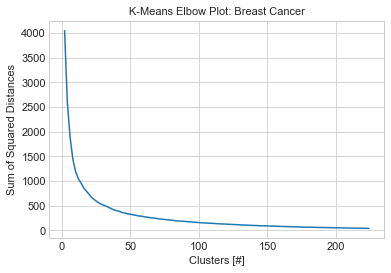

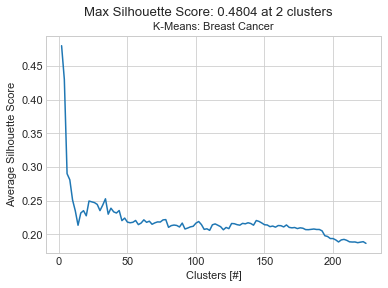

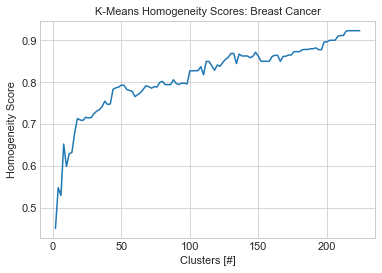

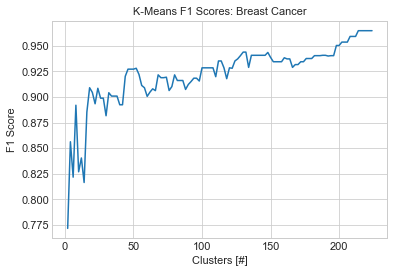

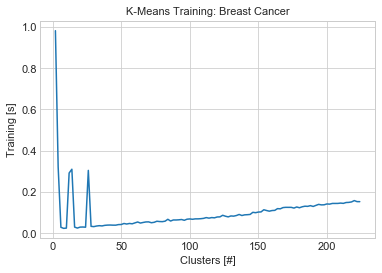

In [10]:
kmns_rn(bc_xtn, bc_ytn, 'Breast Cancer')

In [11]:
mn = KMeans(random_state=7, n_init=10, n_jobs=-1, n_clusters=24)
eval_kmns(mn, bc_xtn, bc_ytn)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.04
No. Iterations to Converge: 12
Recall:    0.90
F1 Score:  0.91
AUC:       0.92
Precision: 0.92
Accuracy:  0.93


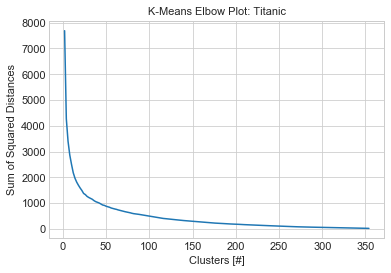

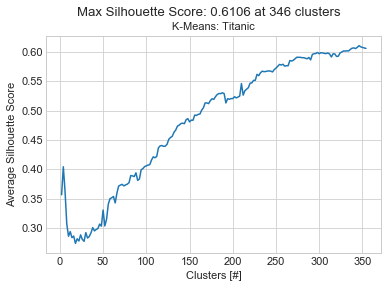

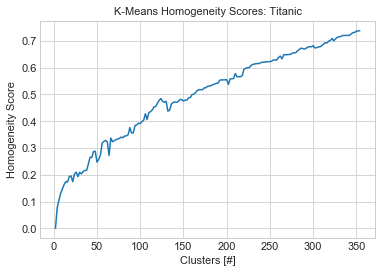

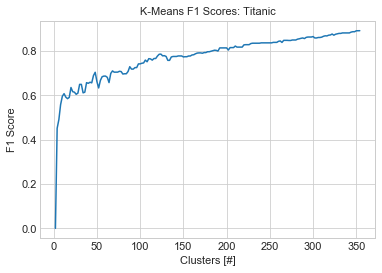

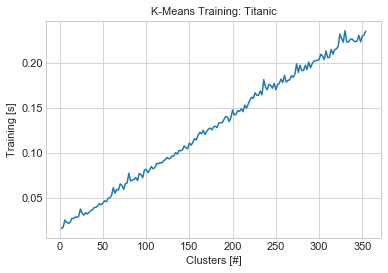

In [12]:
kmns_rn(tt_xtn, tt_ytn, 'Titanic')

In [13]:
mn = KMeans(n_init=10, random_state=7, n_jobs=-1, n_clusters=100)
eval_kmns(mn, tt_xtn, tt_ytn)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.07
No. Iterations to Converge: 6
Recall:    0.71
F1 Score:  0.74
AUC:       0.79
Precision: 0.77
Accuracy:  0.81


# Expectation Maximization

In [14]:
def em_rn(inp, out, ttl):

    kdist = list(my.arange(2, int(len(inp)/2-1), 5))
    sil_scr = []; f1_scr = []; hom_scr = []; trn_tm = []; aic_scr = []; bic_scr = []
    
    for kd in kdist:
        strt = timeit.default_timer()
        em = EM(n_init=1, n_components=kd, covariance_type='diag', warm_start=True, random_state=7).fit(inp)
        fin = timeit.default_timer()
        trn_tm.append(fin - strt)
        
        lbls = em.predict(inp)
        sil_scr.append(sl_score(inp, lbls))
        y_mode_vote = cluster_prd(out,lbls)
        f1_scr.append(f1_score(out, y_mode_vote))
        hom_scr.append(homogeneity_score(out, lbls))
        aic_scr.append(em.aic(inp))
        bic_scr.append(em.bic(inp))
        
    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kdist, sil_scr)
    ppt.grid(True)
    ppt.xlabel('Distributions [#]')
    ppt.ylabel('Average Silhouette Score')
    ppt.title('EM Elbow Plot: '+ ttl)
    ppt.suptitle('Max Silhouette Score: ' + str(round(max(sil_scr),4)) + ' at ' + str(kdist[sil_scr.index(max(sil_scr))]) + ' distributions')
    ppt.show()
   
    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kdist, hom_scr)
    ppt.grid(True)
    ppt.xlabel('Distributions [#]')
    ppt.ylabel('Homogeneity Score')
    ppt.title('EM Homogeneity Scores: '+ ttl)
    ppt.show()

    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kdist, trn_tm)
    ppt.grid(True)
    ppt.xlabel('Distributions [#]')
    ppt.ylabel('Training [s]')
    ppt.title('EM Training Time: '+ ttl)
    ppt.show() 
    
    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kdist, f1_scr)
    ppt.grid(True)
    ppt.xlabel('Distributions [#]')
    ppt.ylabel('F1 Score')
    ppt.title('EM F1 Scores: '+ ttl)
    ppt.show()

    fig = ppt.figure()
    ax = fig.add_subplot(111)
    ax.plot(kdist, aic_scr, label='AIC')
    ax.plot(kdist, bic_scr, label='BIC')
    ppt.grid(True)
    ppt.ylabel('Complexity Score')
    ppt.xlabel('Distributions [#]')
    ppt.title('EM Model Complexity: '+ ttl)
    ppt.legend(loc="best")
    ppt.show()
    
def eval_em(em, inp, out):
    strt = timeit.default_timer()
    em.fit(inp, out)
    fin = timeit.default_timer()
    trn_tm = fin - strt
    y_md_vt = cluster_prd(out, em.predict(inp))

    print("Evaluation Metrics via Mode Cluster Vote")
    print("------------------------------------------")
    print("Training [s]:   "+"{:.2f}".format(trn_tm))
    print("No. Iterations to Converge: {}".format(em.n_iter_))
    print("Log-likelihood Lower Bound: {:.2f}".format(em.lower_bound_))
    print("Recall:    "+"{:.2f}".format(recall_score(out, y_md_vt)))
    print("F1 Score:  "+"{:.2f}".format(f1_score(out, y_md_vt)))
    print("AUC:       "+"{:.2f}".format(roc_auc_score(out, y_md_vt)))
    print("Precision: "+"{:.2f}".format(precision_score(out, y_md_vt)))
    print("Accuracy:  "+"{:.2f}".format(accuracy_score(out, y_md_vt)))
    

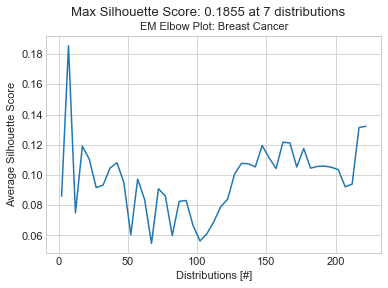

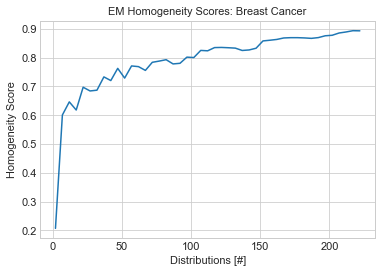

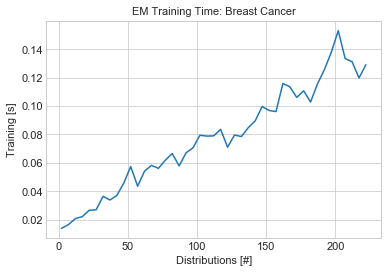

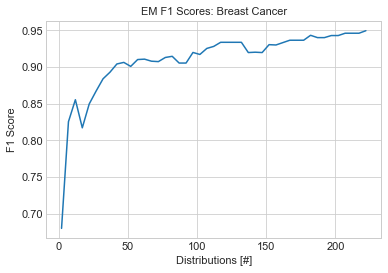

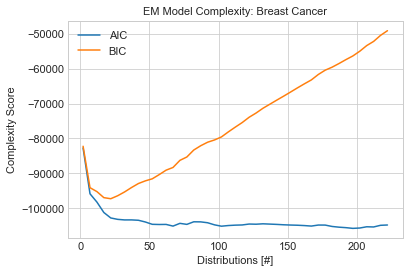

In [15]:
em_rn(bc_xtn, bc_ytn,'Breast Cancer')

In [16]:
em = EM(n_init=1, n_components=15, covariance_type='diag', warm_start=True, random_state=7)
eval_em(em, bcx, bcy)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.03
No. Iterations to Converge: 25
Log-likelihood Lower Bound: 112.08
Recall:    0.90
F1 Score:  0.86
AUC:       0.89
Precision: 0.82
Accuracy:  0.89


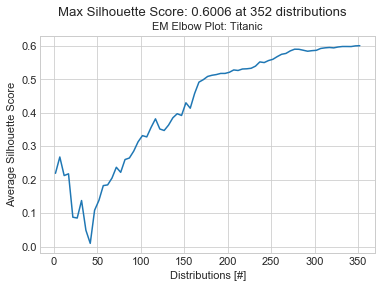

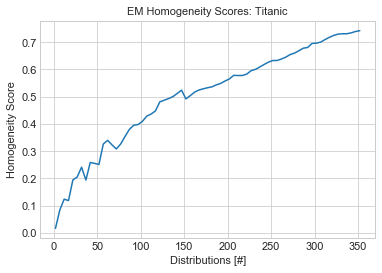

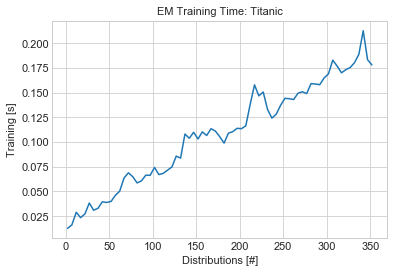

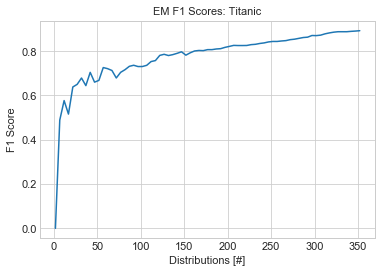

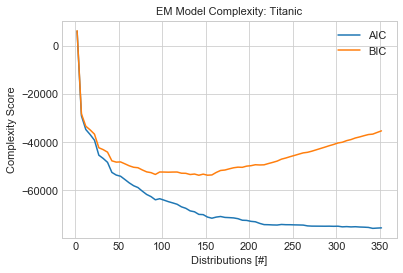

In [17]:
em_rn(tt_xtn,tt_ytn,'Titanic')

In [18]:
em = EM(n_components=97, n_init=1, covariance_type='diag', warm_start=True, random_state=7)
eval_em(em,ttx, tty)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.08
No. Iterations to Converge: 14
Log-likelihood Lower Bound: 47.73
Recall:    0.68
F1 Score:  0.71
AUC:       0.77
Precision: 0.75
Accuracy:  0.79


# Dimensionality Reduction

In [19]:
def PCA_rn(inp, out, ttl):
    
    pca = PCA(random_state=7).fit(inp)
    cm_var = my.cumsum(pca.explained_variance_ratio_)

    fig, ax1 = ppt.subplots()
    ax1.plot(list(range(len(pca.explained_variance_ratio_))), cm_var, 'm-')
    ax1.set_ylabel('Cumulative Exp. Variance Ratio', color='m')
    ax1.tick_params('y', colors='m')
    ax1.set_xlabel('Principal Components')
    ppt.grid(False)

    ax2 = ax1.twinx()
    ax2.plot(list(range(len(pca.singular_values_))), pca.singular_values_, 'b-')
    ax2.tick_params('y', colors='b')
    ax2.set_ylabel('Eigenvalues', color='b')
    ppt.grid(False)

    ppt.title("PCA Eigenvalues & Explained Variance: "+ ttl)
    fig.tight_layout()
    ppt.show()
    
def ICA_rn(inp, out, ttl):
    
    krt = []
    dms = list(my.arange(2,(inp.shape[1]-1),3))
    dms.append(inp.shape[1])
    ica = ICA(random_state=7)

    for dm in dms:
        ica.set_params(n_components=dm)
        tmp = da.DataFrame(ica.fit_transform(inp))
        tmp = tmp.kurt(axis=0)
        krt.append(tmp.abs().mean())

    ppt.figure()
    ppt.title("ICA Kurtosis: "+ ttl)
    ppt.ylabel("Average Kurtosis Across IC")
    ppt.xlabel("Indep. Components")
    ppt.plot(dms, krt, 'b-')
    ppt.grid(False)
    ppt.show()

def RCA_rn(inp, out, ttl):
    
    dims = list(my.arange(2,(inp.shape[1]-1),3))
    dims.append(inp.shape[1])
    pdc = defaultdict(dict)

    for k, dm in product(range(5),dims):
        rp = RCA(n_components=dm, random_state=k)
        pdc[dm][k] = pairws_dist_corr(rp.fit_transform(inp), inp)
    pdc = da.DataFrame(pdc).T
    avg_rcn = pdc.mean(axis=1).tolist()
    std_rcn = pdc.std(axis=1).tolist()


    fig, ax1 = ppt.subplots()
    ax1.plot(dims, avg_rcn, 'm-')
    ax1.set_ylabel('Mean Reconstruction Correlation', color='m')
    ax1.tick_params('y', colors='m')
    ax1.set_xlabel('Random Components')
    ppt.grid(False)

    ax2 = ax1.twinx()
    ax2.plot(dims, std_rcn, 'b-')
    ax2.set_ylabel('STD Reconstruction Correlation', color='b')
    ax2.tick_params('y', colors='b')
    ppt.grid(False)

    ppt.title("Random Components for 5 Restarts: "+ ttl)
    fig.tight_layout()
    ppt.show()
    
def RFC_rn(inp, out, orig_df):
    rc = RFC(random_state=7, n_estimators=100, min_samples_leaf=round(len(inp)*.01), n_jobs=-1)
    impnc = rc.fit(inp, out).feature_importances_ 
    impnc = da.DataFrame(impnc, columns=['Feature Importance'],index=orig_df.columns[1::])
    impnc.sort_values(by=['Feature Importance'], inplace=True, ascending=False)
    impnc['Cumulative Sum'] = impnc['Feature Importance'].cumsum()
    return impnc[impnc['Cumulative Sum']<=0.95], impnc.index.tolist()


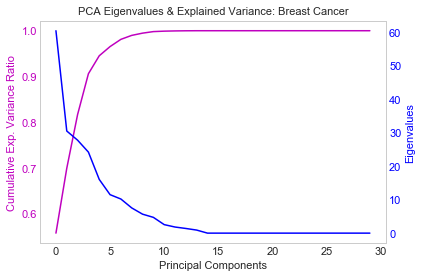

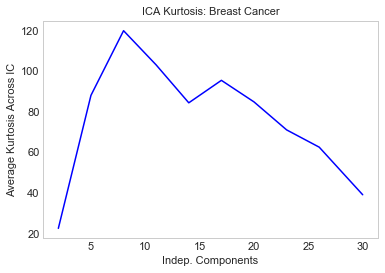

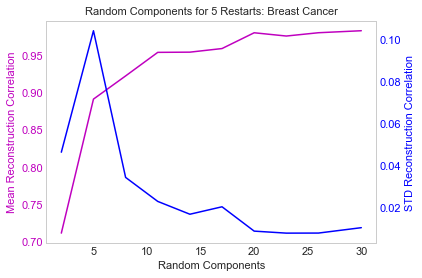

In [20]:
PCA_rn(bc_xtn, bc_ytn,"Breast Cancer")
ICA_rn(bc_xtn, bc_ytn,"Breast Cancer")
RCA_rn(bc_xtn, bc_ytn,"Breast Cancer")


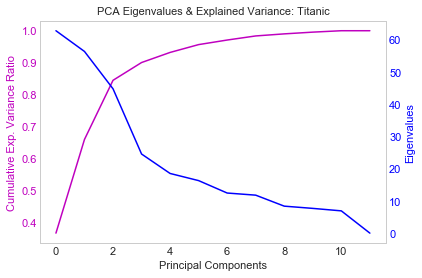

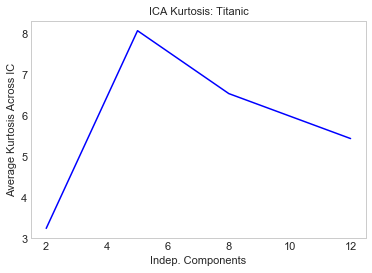

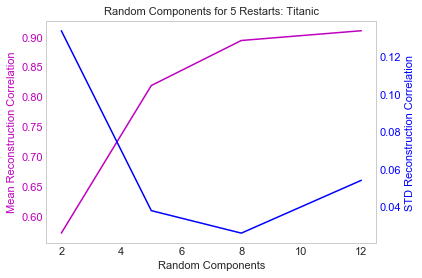

In [21]:
PCA_rn(tt_xtn, tt_ytn,"Titanic")
ICA_rn(tt_xtn, tt_ytn,"Titanic")
RCA_rn(tt_xtn, tt_ytn,"Titanic")


# Breast Cancer with Modified Data

In [22]:
imp_bc, topcols_bc = RFC_rn(bcx, bcy, bc_df)
pca_bc = PCA(n_components=5, random_state=7).fit_transform(bcx)
ica_bc = ICA(n_components=7, random_state=7).fit_transform(bcx)
rca_bc = RCA(n_components=11, random_state=7).fit_transform(bcx)
rfc_bc = bc_df[topcols_bc]
rfc_bc = my.array(rfc_bc.values, dtype='int64')


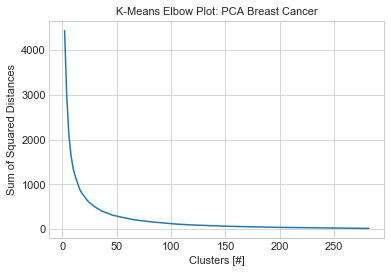

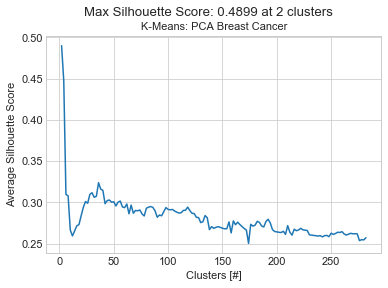

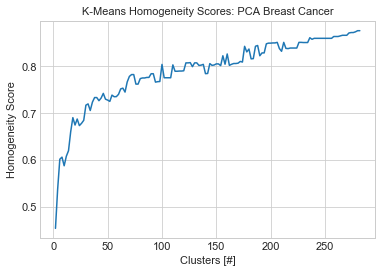

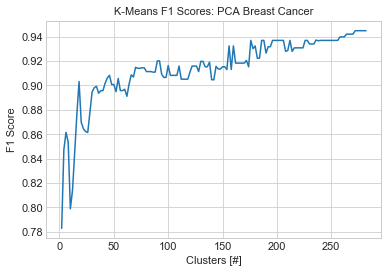

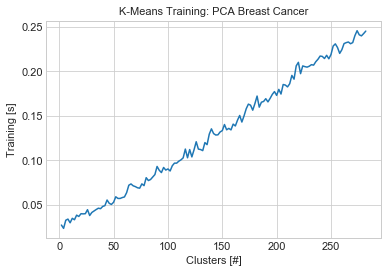

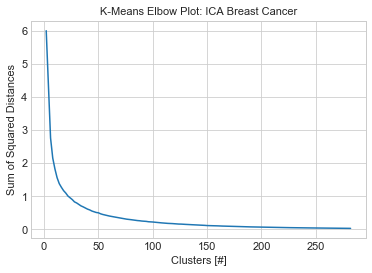

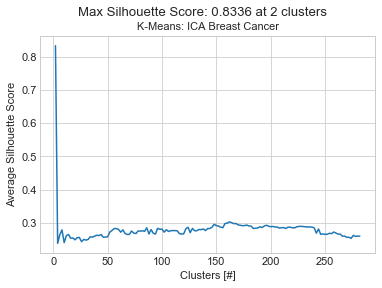

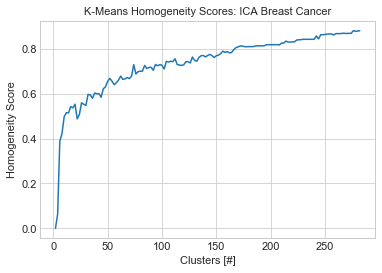

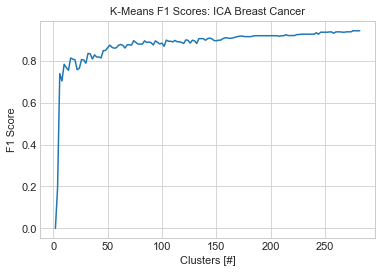

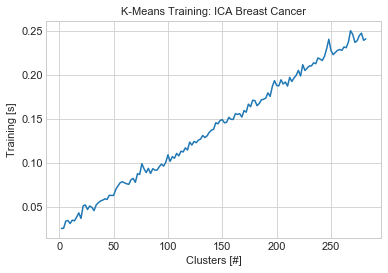

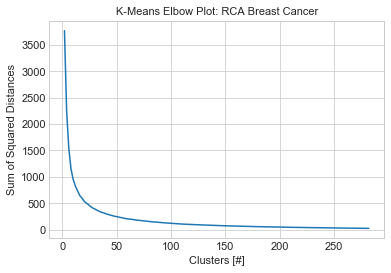

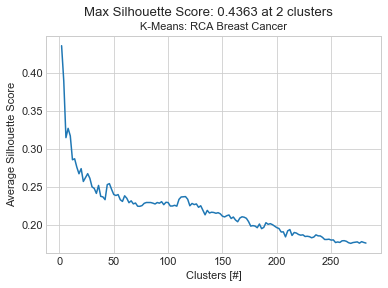

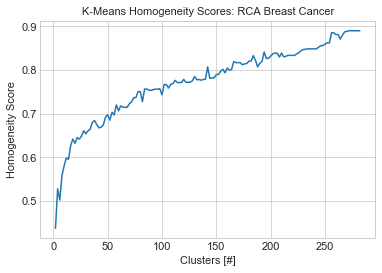

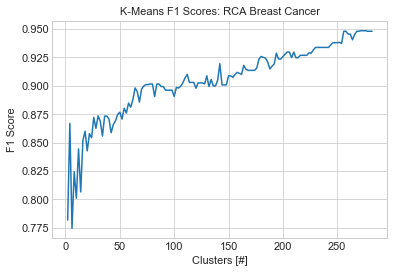

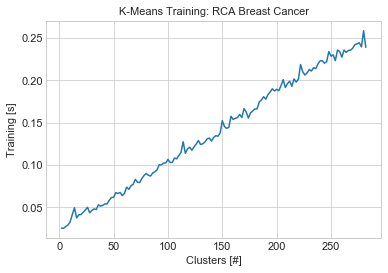

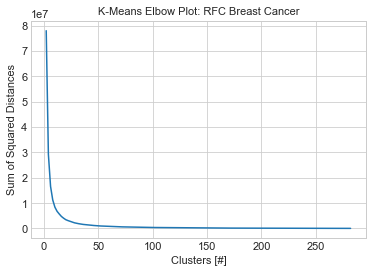

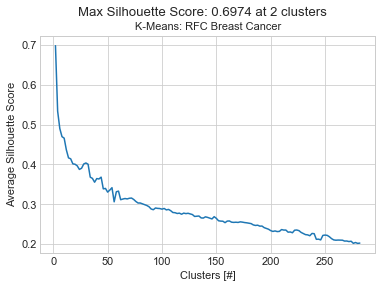

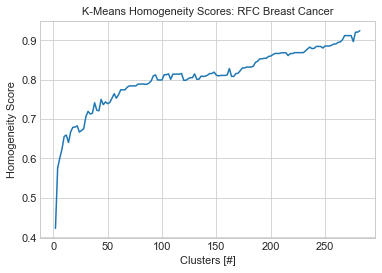

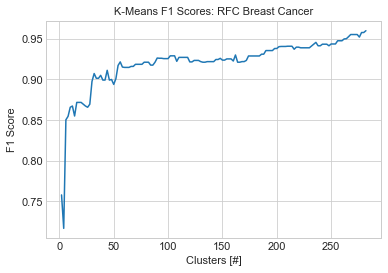

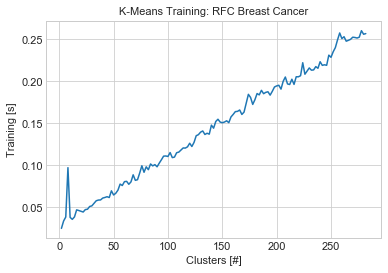

In [23]:
kmns_rn(pca_bc,bcy,'PCA Breast Cancer')
kmns_rn(ica_bc,bcy,'ICA Breast Cancer')
kmns_rn(rca_bc,bcy,'RCA Breast Cancer')
kmns_rn(rfc_bc,bcy,'RFC Breast Cancer')


In [24]:
eval_kmns(KMeans(n_jobs=-1, n_clusters=24, n_init=10, random_state=7),pca_bc,bcy)
eval_kmns(KMeans(n_jobs=-1, n_clusters=24, n_init=10, random_state=7),ica_bc,bcy)
eval_kmns(KMeans(n_jobs=-1, n_clusters=24, n_init=10, random_state=7),rca_bc,bcy)
eval_kmns(KMeans(n_jobs=-1, n_clusters=24, n_init=10, random_state=7),rfc_bc,bcy)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.05
No. Iterations to Converge: 16
Recall:    0.80
F1 Score:  0.86
AUC:       0.88
Precision: 0.94
Accuracy:  0.91
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.04
No. Iterations to Converge: 14
Recall:    0.70
F1 Score:  0.76
AUC:       0.81
Precision: 0.84
Accuracy:  0.84
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.05
No. Iterations to Converge: 12
Recall:    0.79
F1 Score:  0.85
AUC:       0.88
Precision: 0.93
Accuracy:  0.90
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.05
No. Iterations to Converge: 8
Recall:    0.80
F1 Score:  0.87
AUC:       0.89
Precision: 0.94
Accuracy:  0.91


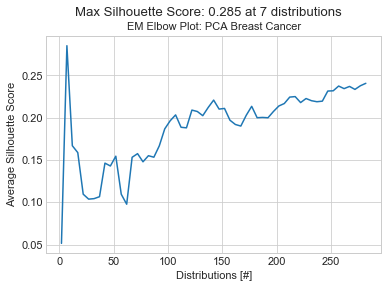

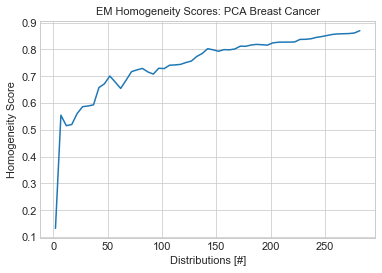

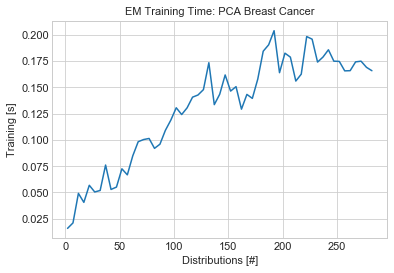

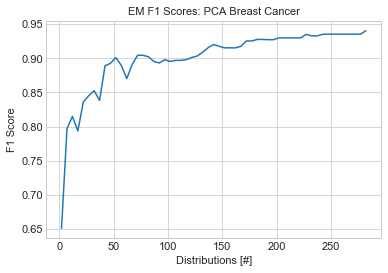

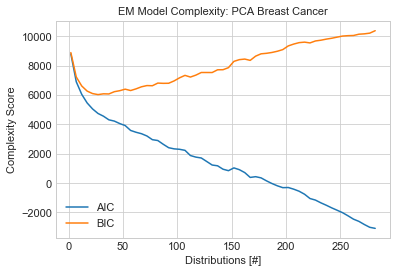

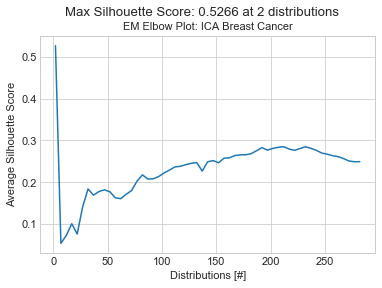

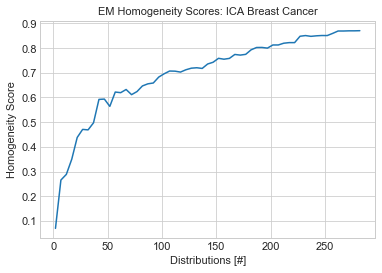

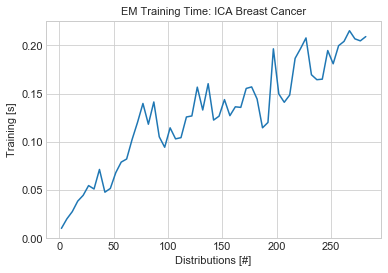

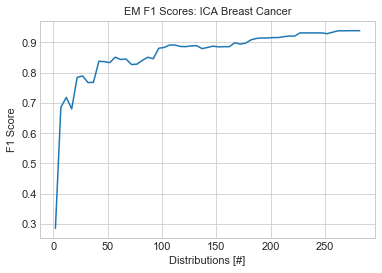

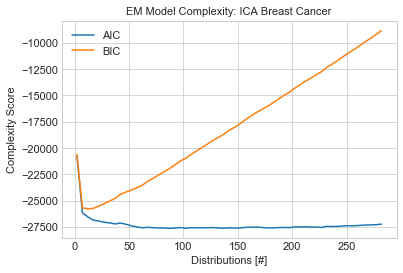

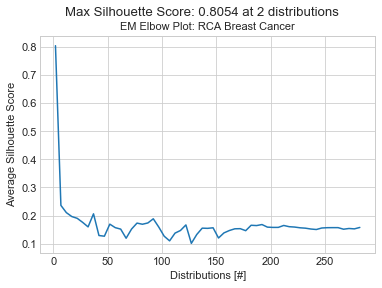

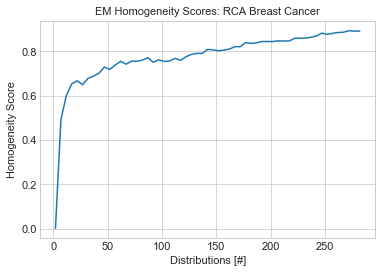

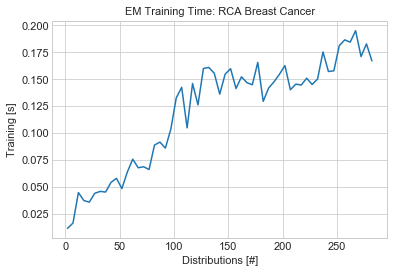

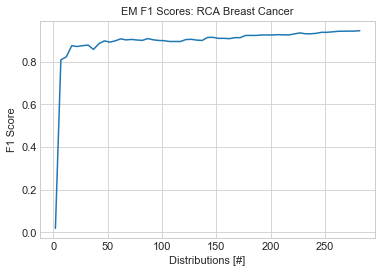

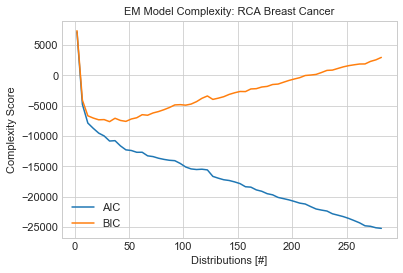

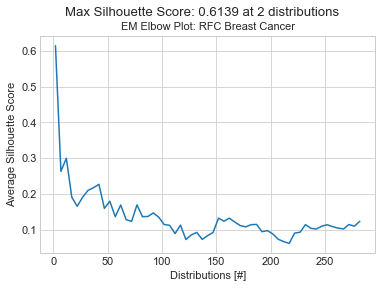

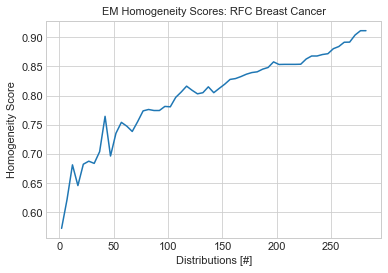

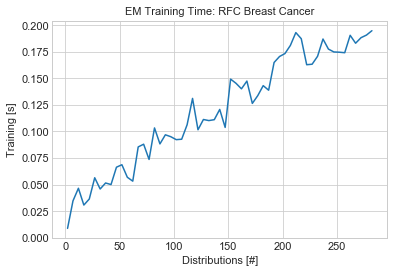

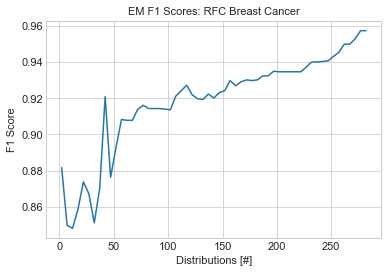

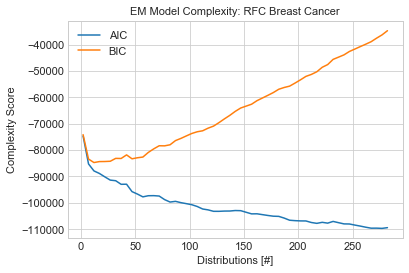

In [25]:
em_rn(pca_bc,bcy,'PCA Breast Cancer')
em_rn(ica_bc,bcy,'ICA Breast Cancer')
em_rn(rca_bc,bcy,'RCA Breast Cancer')
em_rn(rfc_bc,bcy,'RFC Breast Cancer')


In [26]:
eval_em(EM(n_init=1, n_components=15, covariance_type='diag', warm_start=True, random_state=7),pca_bc,bcy)
eval_em(EM(n_init=1, n_components=15, covariance_type='diag', warm_start=True, random_state=7),ica_bc,bcy)
eval_em(EM(n_init=1, n_components=15, covariance_type='diag', warm_start=True, random_state=7),rca_bc,bcy)
eval_em(EM(n_init=1, n_components=15, covariance_type='diag', warm_start=True, random_state=7),rfc_bc,bcy)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.03
No. Iterations to Converge: 23
Log-likelihood Lower Bound: -4.75
Recall:    0.68
F1 Score:  0.80
AUC:       0.83
Precision: 0.97
Accuracy:  0.87
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.04
No. Iterations to Converge: 36
Log-likelihood Lower Bound: 23.88
Recall:    0.83
F1 Score:  0.75
AUC:       0.80
Precision: 0.68
Accuracy:  0.79
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.04
No. Iterations to Converge: 26
Log-likelihood Lower Bound: 7.87
Recall:    0.82
F1 Score:  0.88
AUC:       0.90
Precision: 0.95
Accuracy:  0.92
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.05
No. Iterations to Converge: 44
Log-likelihood Lower Bound: 79.01
Recall:    0.84
F1 Score:  0.89
AUC:       0.90
Precision: 0.94
Accuracy:  0.92


# Titanic - K-Means and EM with Modified Data

In [27]:
imp_tt, topcols_tt = RFC_rn(ttx, tty, tt_df)
pca_tt = PCA(random_state=7, n_components=6).fit_transform(ttx)
ica_tt = ICA(random_state=7, n_components=5).fit_transform(ttx)
rca_tt = RCA(random_state=7, n_components=8).fit_transform(ttx)
rfc_tt = tt_df[topcols_tt]
rfc_tt = my.array(rfc_tt.values,dtype='int64')


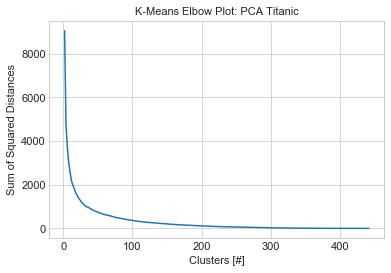

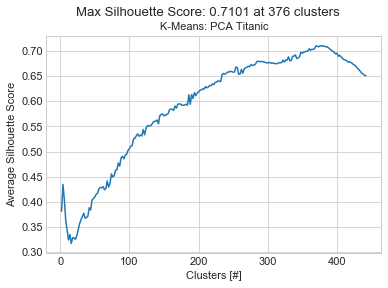

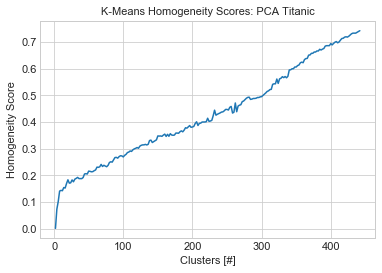

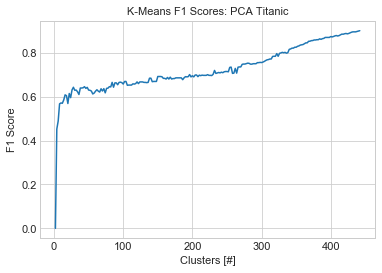

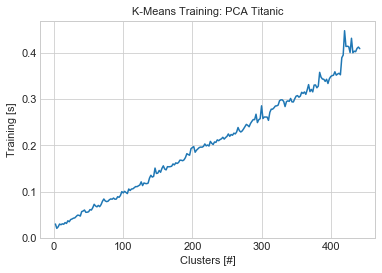

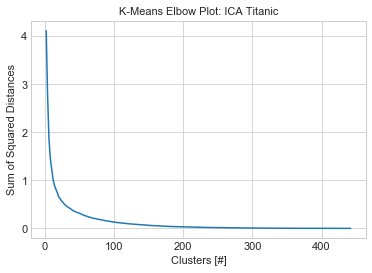

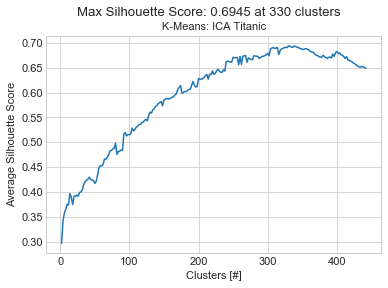

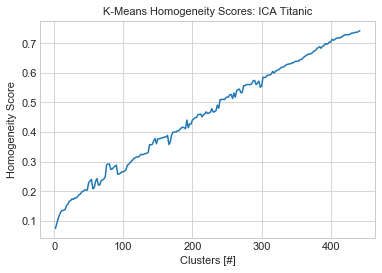

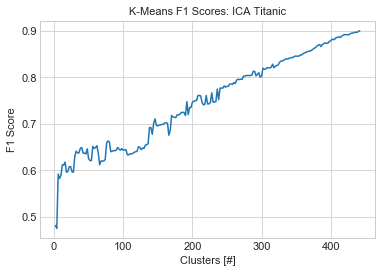

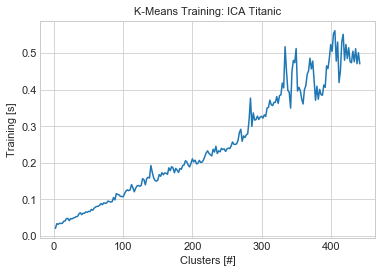

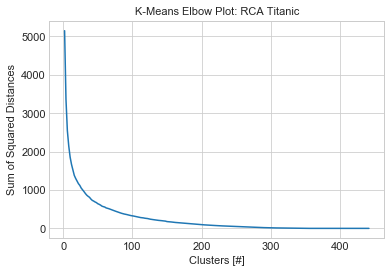

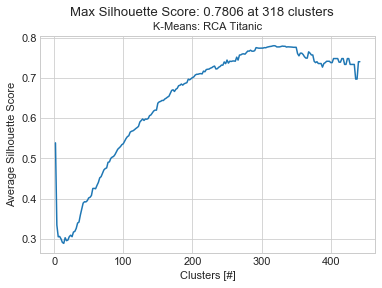

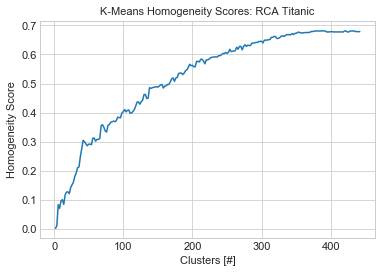

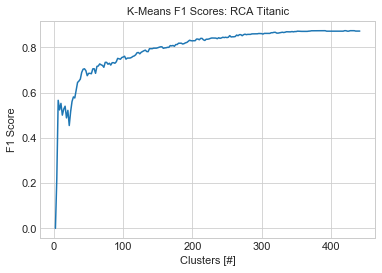

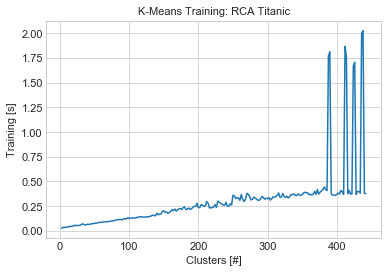

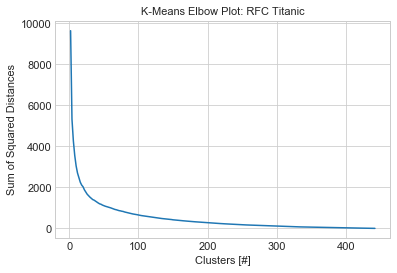

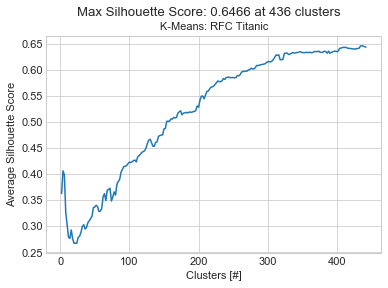

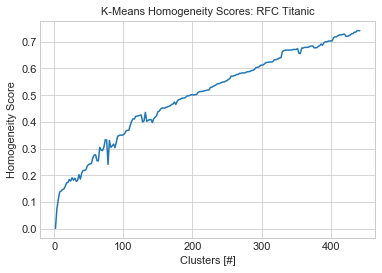

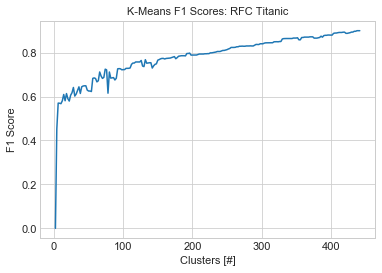

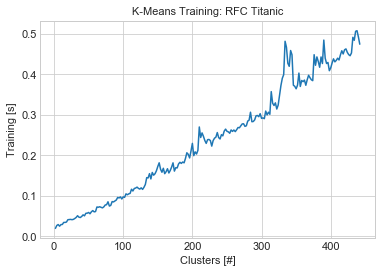

In [28]:
kmns_rn(pca_tt,tty,'PCA Titanic')
kmns_rn(ica_tt,tty,'ICA Titanic')
kmns_rn(rca_tt,tty,'RCA Titanic')
kmns_rn(rfc_tt,tty,'RFC Titanic')


In [29]:
eval_kmns(KMeans(n_init=10, n_clusters=100, random_state=7, n_jobs=-1), pca_tt,tty)
eval_kmns(KMeans(n_init=10, n_clusters=100, random_state=7, n_jobs=-1), ica_tt,tty)
eval_kmns(KMeans(n_init=10, n_clusters=100, random_state=7, n_jobs=-1), rca_tt,tty)
eval_kmns(KMeans(n_init=10, n_clusters=100, random_state=7, n_jobs=-1), rfc_tt,tty)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.12
No. Iterations to Converge: 6
Recall:    0.60
F1 Score:  0.66
AUC:       0.73
Precision: 0.73
Accuracy:  0.76
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.11
No. Iterations to Converge: 4
Recall:    0.56
F1 Score:  0.64
AUC:       0.72
Precision: 0.75
Accuracy:  0.76
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.11
No. Iterations to Converge: 4
Recall:    0.74
F1 Score:  0.76
AUC:       0.80
Precision: 0.78
Accuracy:  0.82
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training Time [s]:   0.15
No. Iterations to Converge: 5
Recall:    0.68
F1 Score:  0.72
AUC:       0.78
Precision: 0.77
Accuracy:  0.80


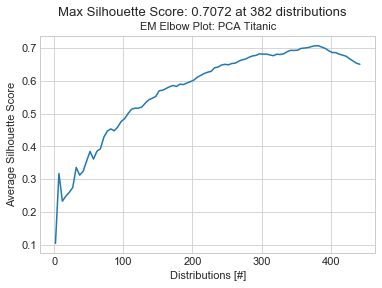

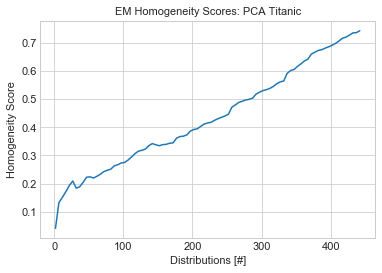

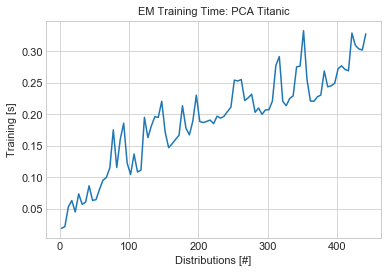

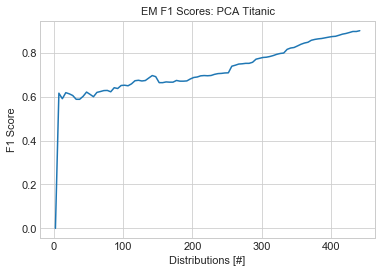

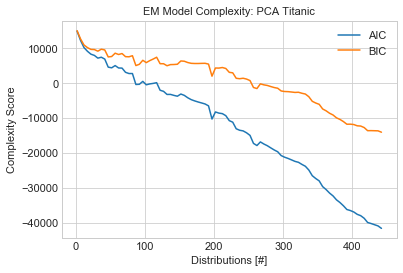

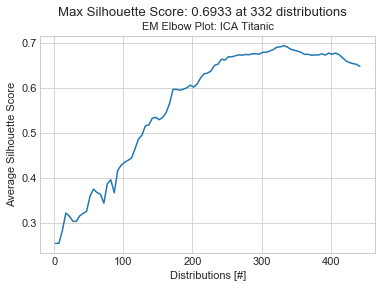

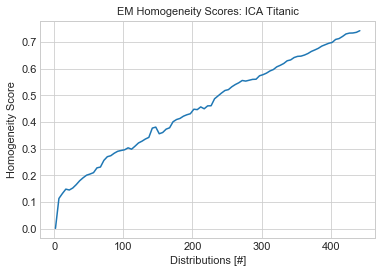

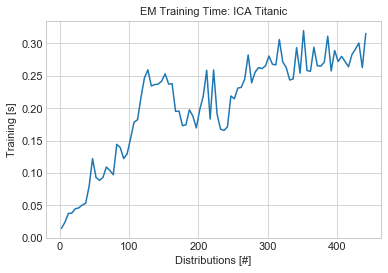

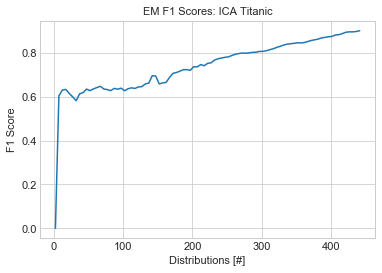

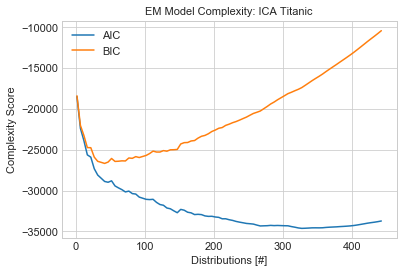

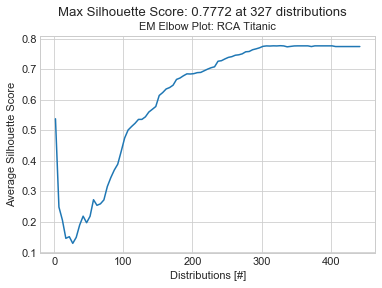

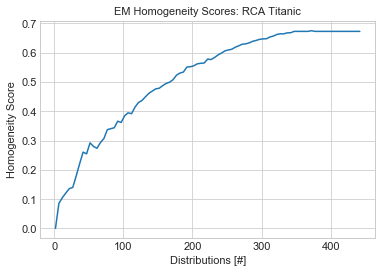

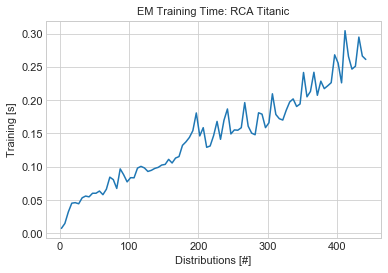

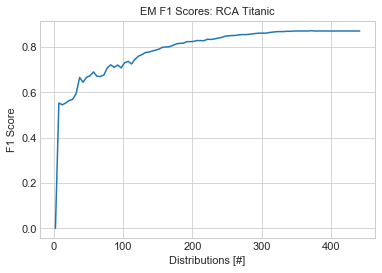

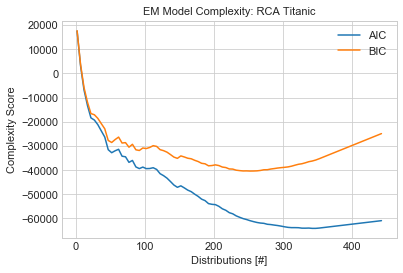

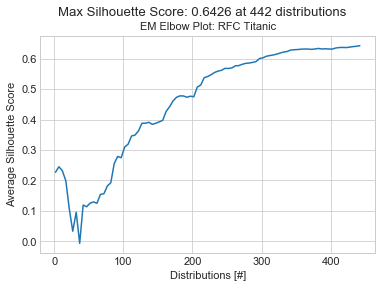

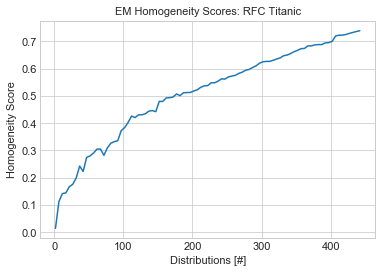

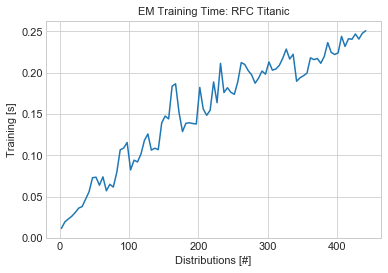

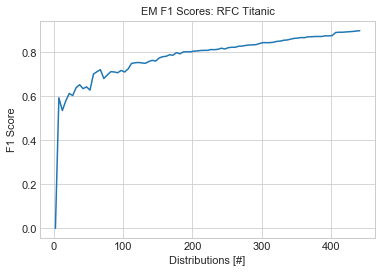

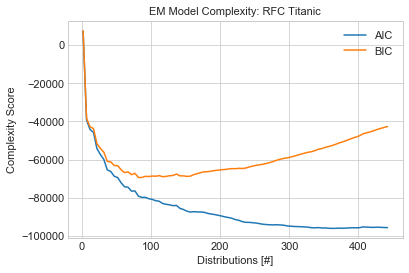

In [30]:
em_rn(pca_tt,tty,'PCA Titanic')
em_rn(ica_tt,tty,'ICA Titanic')
em_rn(rca_tt,tty,'RCA Titanic')
em_rn(rfc_tt,tty,'RFC Titanic')


In [31]:
eval_em(EM(n_init=1, n_components=97, covariance_type='diag', warm_start=True, random_state=7),pca_tt,tty)
eval_em(EM(n_init=1, n_components=97, covariance_type='diag', warm_start=True, random_state=7),ica_tt,tty)
eval_em(EM(n_init=1, n_components=97, covariance_type='diag', warm_start=True, random_state=7),rca_tt,tty)
eval_em(EM(n_init=1, n_components=97, covariance_type='diag', warm_start=True, random_state=7),rfc_tt,tty)


Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.11
No. Iterations to Converge: 15
Log-likelihood Lower Bound: 1.13
Recall:    0.58
F1 Score:  0.65
AUC:       0.73
Precision: 0.73
Accuracy:  0.76
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.12
No. Iterations to Converge: 19
Log-likelihood Lower Bound: 18.56
Recall:    0.55
F1 Score:  0.64
AUC:       0.72
Precision: 0.77
Accuracy:  0.76
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.08
No. Iterations to Converge: 10
Log-likelihood Lower Bound: 23.60
Recall:    0.65
F1 Score:  0.71
AUC:       0.77
Precision: 0.77
Accuracy:  0.79
Evaluation Metrics via Mode Cluster Vote
------------------------------------------
Training [s]:   0.10
No. Iterations to Converge: 18
Log-likelihood Lower Bound: 47.88
Recall:    0.65
F1 Score:  0.72
AUC:       0.77
Precision: 0.79
Accuracy:  0.80


# Neural Net on Projected Data

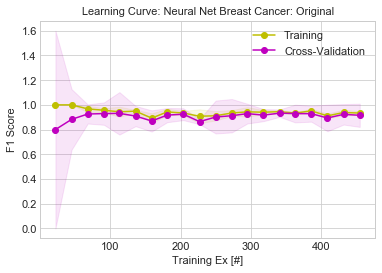

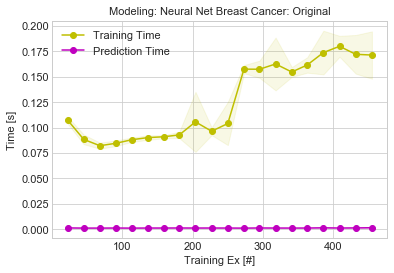

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.88
Precision: 1.00
Accuracy:  0.96
AUC:  0.94
F1 Score:  0.93
Training Time [s]:   0.20900
Prediction Time [s]: 0.00022



In [32]:
org_est = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_org, trn_scr_org, fit_tm_org, prd_tm_org = pltlc(org_est, bc_xtn, bc_ytn, ttl="Neural Net Breast Cancer: Original")

class_eval(org_est, bc_xtn, bc_xtt, bc_ytn, bc_ytt)


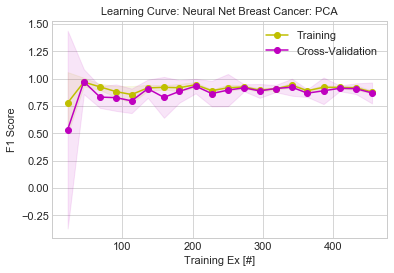

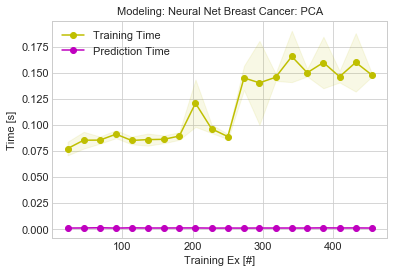

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.87
Precision: 0.97
Accuracy:  0.95
AUC:  0.93
F1 Score:  0.92
Training Time [s]:   0.22104
Prediction Time [s]: 0.00030



In [33]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(pca_bc),my.array(bcy), test_size=0.20)
pca_est = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_pca, trn_scr_pca, fit_tm_pca, prd_tm_pca = pltlc(pca_est, X_trn, y_trn, ttl="Neural Net Breast Cancer: PCA")

class_eval(pca_est, X_trn, X_tst, y_trn, y_tst)


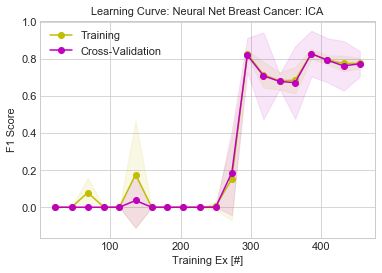

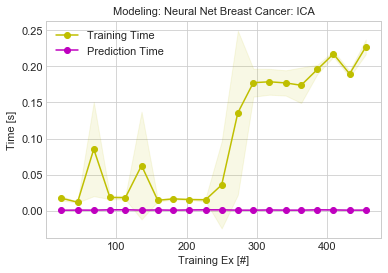

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.77
Precision: 0.95
Accuracy:  0.89
AUC:  0.87
F1 Score:  0.85
Training Time [s]:   0.22519
Prediction Time [s]: 0.00019



In [34]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(ica_bc),my.array(bcy), test_size=0.20)
ica_est = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_ica, trn_scr_ica, fit_tm_ica, prd_tm_ica = pltlc(ica_est, X_trn, y_trn, ttl="Neural Net Breast Cancer: ICA")

class_eval(ica_est, X_trn, X_tst, y_trn, y_tst)


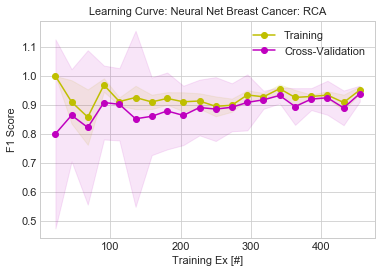

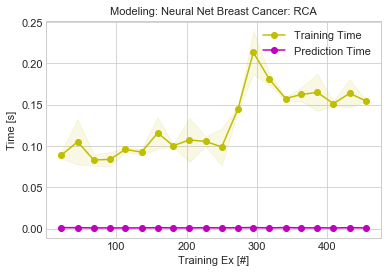

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.91
Precision: 0.98
Accuracy:  0.96
AUC:  0.95
F1 Score:  0.94
Training Time [s]:   0.21540
Prediction Time [s]: 0.00020



In [35]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(rca_bc),my.array(bcy), test_size=0.20)
rca_est = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_rca, trn_scr_rca, fit_tm_rca, prd_tm_rca = pltlc(rca_est, X_trn, y_trn, ttl="Neural Net Breast Cancer: RCA")

class_eval(rca_est, X_trn, X_tst, y_trn, y_tst)


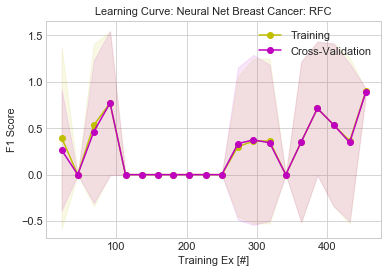

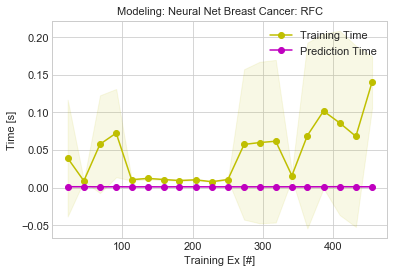

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.00
Precision: 0.00
Accuracy:  0.69
AUC:  0.50
F1 Score:  0.00
Training Time [s]:   0.02510
Prediction Time [s]: 0.00019



In [36]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(rfc_bc),my.array(bcy), test_size=0.20)
rfc_est = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_rfc, trn_scr_rfc, fit_tm_rfc, prd_tm_rfc = pltlc(rfc_est, X_trn, y_trn, ttl="Neural Net Breast Cancer: RFC")

class_eval(rfc_est, X_trn, X_tst, y_trn, y_tst)


# Comparison Plots

In [37]:
def lrn_tm(n,org_lrn, pca_lrn, ica_lrn, rca_lrn, rfc_lrn, ttl):
    
    ppt.figure()
    ppt.title("Learning Rates: " + ttl)
    ppt.xlabel("Training Examples")
    ppt.ylabel("F1 Score")
    ppt.plot(n, org_lrn, '-', color="k", label="Original")
    ppt.plot(n, rca_lrn, '-', color="g", label="RCA")
    ppt.plot(n, pca_lrn, '-', color="b", label="PCA")
    ppt.plot(n, rfc_lrn, '-', color="m", label="RFC")
    ppt.plot(n, ica_lrn, '-', color="r", label="ICA")
    ppt.legend(loc="best")
    ppt.show() 

def prd_tm(n,org_prd, pca_prd, ica_prd, rca_prd, rfc_prd, ttl):
    
    ppt.figure()
    ppt.title("Prediction Times: " + ttl)
    ppt.xlabel("Examples")
    ppt.ylabel("Prediction Time [s]")
    ppt.plot(n, org_prd, '-', color="k", label="Original")
    ppt.plot(n, rca_prd, '-', color="g", label="RCA")
    ppt.plot(n, pca_prd, '-', color="b", label="PCA")
    ppt.plot(n, rfc_prd, '-', color="m", label="RFC")
    ppt.plot(n, ica_prd, '-', color="r", label="ICA")
    ppt.legend(loc="best")
    ppt.show()
    
def ft_tm(sz, org_ft, pca_ft, ica_ft, rca_ft, rfc_ft, ttl):
    
    ppt.figure()
    ppt.title("Training Times: " + ttl)
    ppt.xlabel("Examples")
    ppt.ylabel("Training [s]")
    ppt.plot(sz, org_ft, '-', color="k", label="Original")
    ppt.plot(sz, rca_ft, '-', color="g", label="RCA")
    ppt.plot(sz, pca_ft, '-', color="b", label="PCA")
    ppt.plot(sz, rfc_ft, '-', color="m", label="RFC")
    ppt.plot(sz, ica_ft, '-', color="r", label="ICA")
    ppt.legend(loc="best")
    ppt.show()


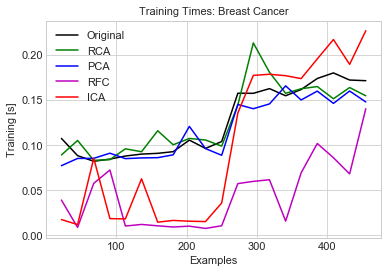

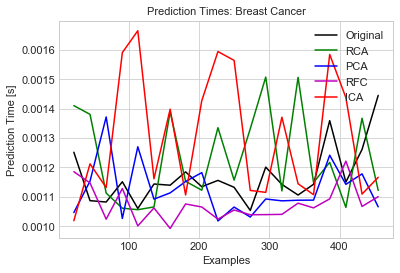

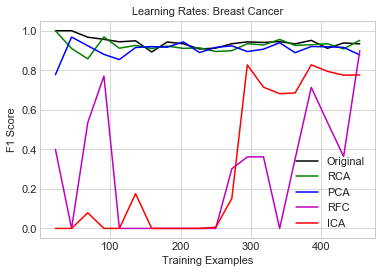

In [38]:
ft_tm(trn_samp_org, fit_tm_org, fit_tm_pca, fit_tm_ica, 
                 fit_tm_rca, fit_tm_rfc, 'Breast Cancer')              
prd_tm(trn_samp_org, prd_tm_org, prd_tm_pca, prd_tm_ica, 
                 prd_tm_rca, prd_tm_rfc, 'Breast Cancer')   
lrn_tm(trn_samp_org, trn_scr_org, trn_scr_pca, trn_scr_ica, 
                 trn_scr_rca, trn_scr_rfc, 'Breast Cancer')  


# Neural Net on Projected Data with Cluster Labels

In [39]:
def addclstrs(X, km_lbls, em_lbls):
    
    df = da.DataFrame(X)
    df['EM'] = em_lbls
    df['KM'] = km_lbls
    col_1hot = ['KM', 'EM']
    one_hot_df = df[col_1hot]
    one_hot_df = da.get_dummies(one_hot_df).astype('category')
    othrs_df = df.drop(col_1hot, axis=1)
    df = da.concat([othrs_df,one_hot_df],axis=1)
    nw_X = my.array(df.values,dtype='int64')   
    
    return nw_X

In [40]:
mn = KMeans(n_clusters=2,n_init=10,random_state=7,n_jobs=-1).fit(bcx)
km_lbls = mn.labels_
em = EM( warm_start=True, n_components=15, covariance_type='diag', random_state=7, n_init=1).fit(bcx)
em_lbls = em.predict(bcx)
clst_org = addclstrs(bcx, km_lbls, em_lbls)
clst_pca = addclstrs(pca_bc, km_lbls, em_lbls)
clst_ica = addclstrs(ica_bc, km_lbls, em_lbls)
clst_rca = addclstrs(rca_bc, km_lbls, em_lbls)
clst_rfc = addclstrs(rfc_bc, km_lbls, em_lbls)


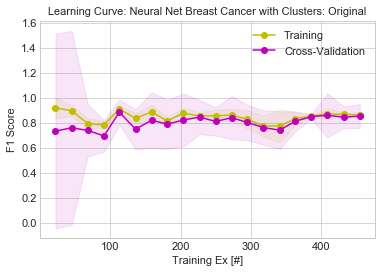

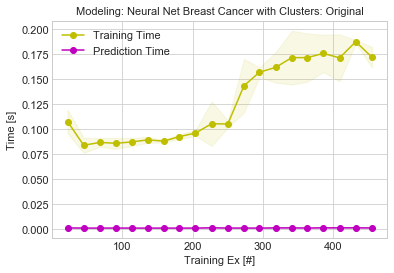

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.72
Precision: 0.94
Accuracy:  0.87
AUC:  0.84
F1 Score:  0.81
Training Time [s]:   0.23021
Prediction Time [s]: 0.00019



In [41]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(clst_org),my.array(bcy), test_size=0.20)
org_est = MLPClassifier(hidden_layer_sizes=(5,), solver='adam', activation='logistic', learning_rate_init=0.01, random_state=7)
trn_samp_org, trn_score_org, fit_tm_org, prd_time_org = pltlc(org_est, X_trn, y_trn, ttl="Neural Net Breast Cancer with Clusters: Original")

class_eval(org_est, X_trn, X_tst, y_trn, y_tst)


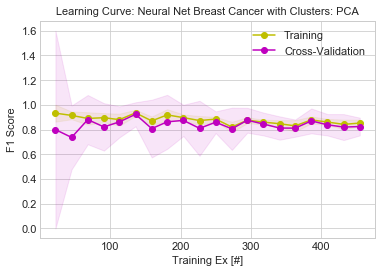

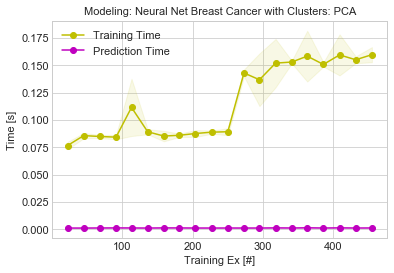

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.77
Precision: 0.93
Accuracy:  0.91
AUC:  0.87
F1 Score:  0.84
Training Time [s]:   0.20750
Prediction Time [s]: 0.00018



In [42]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(clst_pca),my.array(bcy), test_size=0.20)
pca_est = MLPClassifier(hidden_layer_sizes=(5,), solver='adam', activation='logistic', learning_rate_init=0.01, random_state=7)
trn_samp_pca, trn_scr_pca, fit_tm_pca, prd_tm_pca = pltlc(pca_est, X_trn, y_trn, ttl="Neural Net Breast Cancer with Clusters: PCA")

class_eval(pca_est, X_trn, X_tst, y_trn, y_tst)


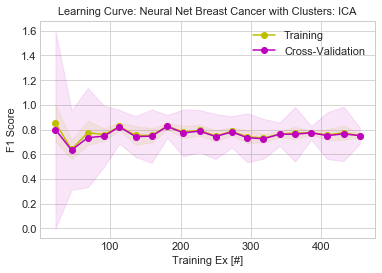

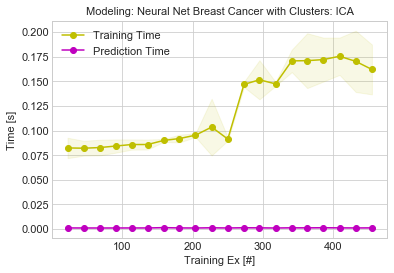

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.62
Precision: 1.00
Accuracy:  0.82
AUC:  0.81
F1 Score:  0.76
Training Time [s]:   0.21326
Prediction Time [s]: 0.00018



In [43]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(clst_ica),my.array(bcy), test_size=0.20)
ica_est = MLPClassifier(hidden_layer_sizes=(5,), solver='adam', activation='logistic', learning_rate_init=0.01, random_state=7)
trn_samp_ica, trn_scr_ica, fit_tm_ica, prd_tm_ica = pltlc(ica_est, X_trn, y_trn, ttl="Neural Net Breast Cancer with Clusters: ICA")

class_eval(ica_est, X_trn, X_tst, y_trn, y_tst)


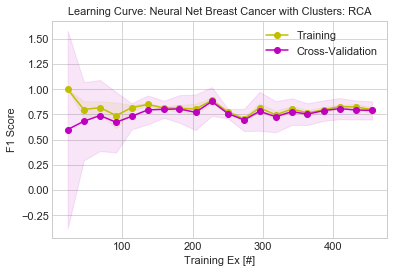

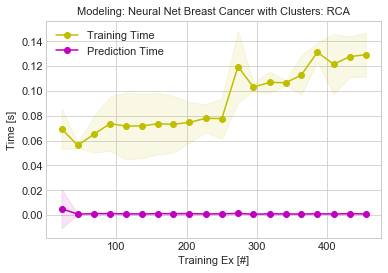

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.67
Precision: 0.91
Accuracy:  0.84
AUC:  0.81
F1 Score:  0.78
Training Time [s]:   0.15714
Prediction Time [s]: 0.00012



In [45]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(clst_rca),my.array(bcy), test_size=0.20)
rca_est = MLPClassifier(hidden_layer_sizes=(5,), solver='adam', activation='logistic', learning_rate_init=0.01, random_state=7)
trn_samp_rca, trn_scr_rca, fit_tm_rca, prd_tm_rca = pltlc(rca_est, X_trn, y_trn, ttl="Neural Net Breast Cancer with Clusters: RCA")

class_eval(rca_est, X_trn, X_tst, y_trn, y_tst)


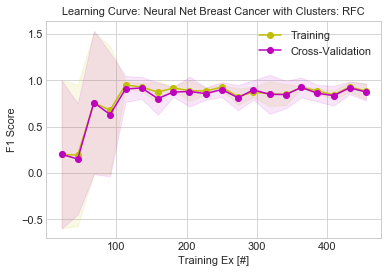

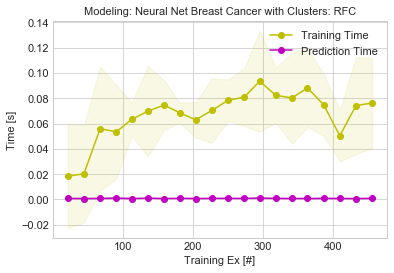

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.77
Precision: 1.00
Accuracy:  0.91
AUC:  0.88
F1 Score:  0.87
Training Time [s]:   0.07734
Prediction Time [s]: 0.00016



In [46]:
X_trn, X_tst, y_trn, y_tst = train_test_split(my.array(clst_rfc),my.array(bcy), test_size=0.20)
rfc_est = MLPClassifier(hidden_layer_sizes=(5,), solver='adam', activation='logistic', learning_rate_init=0.01, random_state=7)
trn_samp_rfc, trn_scr_rfc, fit_tm_rfc, prd_tm_rfc = pltlc(rfc_est, X_trn, y_trn, ttl="Neural Net Breast Cancer with Clusters: RFC")

class_eval(rfc_est, X_trn, X_tst, y_trn, y_tst)


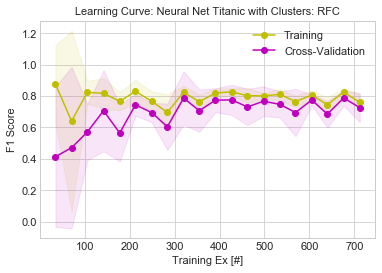

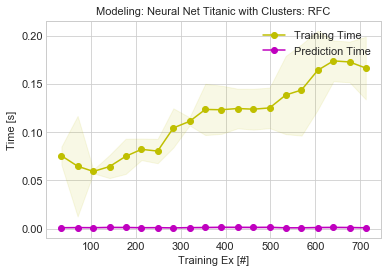

Evaluation Metrics on Test Data
--------------------------------
Recall: 0.63
Precision: 0.80
Accuracy:  0.82
AUC:  0.77
F1 Score:  0.70
Training Time [s]:   0.17428
Prediction Time [s]: 0.00012



In [47]:
mn_tt = KMeans(n_init=10, n_jobs=-1, n_clusters=100, random_state=7).fit(ttx)
km_labels_tt = mn_tt.labels_
em_tt = EM(covariance_type='diag', n_components=97, n_init=1, random_state=7, warm_start=True).fit(ttx)
em_labels_tt = em_tt.predict(ttx)
clust_rfc_tt = addclstrs(rfc_tt,km_labels_tt,em_labels_tt)


X_trn_tt, X_tst_tt, y_trn_tt, y_tst_tt = train_test_split(my.array(clust_rfc_tt),my.array(tty), test_size=0.20)
rfc_est_tt = MLPClassifier(solver='adam', hidden_layer_sizes=(5,), activation='logistic', random_state=7, learning_rate_init=0.01)
trn_samp_rfc_tt, trn_scr_rfc_tt, fit_tm_rfc_tt, prd_tm_rfc_tt = pltlc(rfc_est_tt, X_trn_tt, y_trn_tt, ttl="Neural Net Titanic with Clusters: RFC")

class_eval(rfc_est_tt, X_trn_tt, X_tst_tt, y_trn_tt, y_tst_tt)


### Datasets with Cluster Labels Evaluation

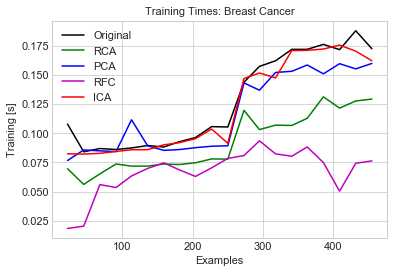

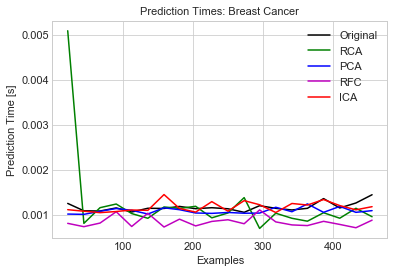

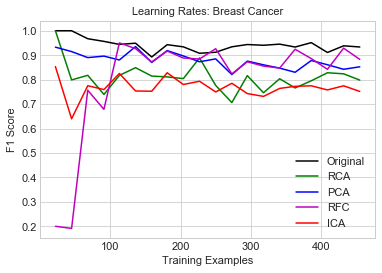

In [48]:
ft_tm(trn_samp_org, fit_tm_org, fit_tm_pca, fit_tm_ica, 
                 fit_tm_rca, fit_tm_rfc, 'Breast Cancer')              
prd_tm(trn_samp_org, prd_tm_org, prd_tm_pca, prd_tm_ica, 
                 prd_tm_rca, prd_tm_rfc, 'Breast Cancer')   
lrn_tm(trn_samp_org, trn_scr_org, trn_scr_pca, trn_scr_ica, 
                 trn_scr_rca, trn_scr_rfc, 'Breast Cancer')  


Text(0, 0.5, 'Feature space for 2nd feature')

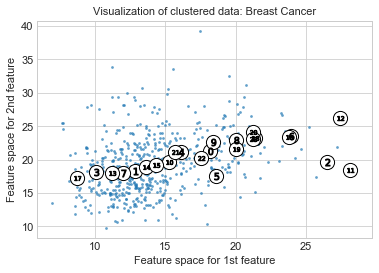

In [49]:
clusterer = KMeans(random_state=7, n_init=10, n_jobs=-1, n_clusters=24)
cluster_labels = clusterer.fit_predict(bc_df)
ppt.scatter(bc_df.iloc[:, 1], bc_df.iloc[:, 2], marker='.', lw=0, s=30, alpha=0.7,
                 edgecolor='k')

cntrs = clusterer.cluster_centers_
ppt.scatter(cntrs[:, 1], cntrs[:, 2], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')

for k, cn in enumerate(cntrs):
    ppt.scatter(cn[1], cn[2], marker='$%d$' % k, alpha=1,
                    s=50, edgecolor='k')

ppt.title("Visualization of clustered data: Breast Cancer")
ppt.xlabel("Feature space for 1st feature")
ppt.ylabel("Feature space for 2nd feature")